In [2]:
import cv2
import numpy as np
import sys
import os

from PIL import Image

In [10]:
path = "data/imagenet/train_images/n10565667_5531_n10565667.JPEG"

img = cv2.imread(path)

Premature end of JPEG file


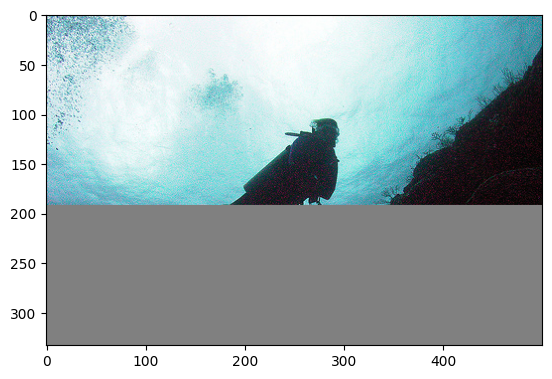

In [11]:
# show image
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [13]:
from src.datasets.imagenet_1k import ImageNetSubsetDataset

In [26]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

root = "/home/haselab/projects/sakai/Fine-tuning-JEPA/data/imagenet"  
# dataset = ImageNetDataset(root=root, train=False, transform=transform, download=False)
# print(f"ImageNet dataset successfully loaded.")
# print(f"Number of images: {len(dataset)}")
# print(f"Sample data: {dataset[0]}")

dataset = ImageNetSubsetDataset(root=root, train=True, transform=transform, download=False, num_samples_per_class=10)
print(f"ImageNetSubsetDataset successfully loaded.")
print(f"Number of images: {len(dataset)}")
print(f"Sample data: {dataset[0]}")
print(f"Sample image shape: {dataset[0]['image'].size()}")
print(f"Sample label: {dataset[0]['label']}")

Extracting subset with 10 samples per class...
ImageNetSubsetDataset successfully loaded.
Number of images: 10000
Sample data: {'index': 0, 'image': tensor([[[0.0588, 0.0902, 0.0824,  ..., 0.0353, 0.0627, 0.0471],
         [0.0353, 0.0314, 0.0471,  ..., 0.0471, 0.0745, 0.0745],
         [0.0392, 0.0549, 0.0588,  ..., 0.0706, 0.0745, 0.0784],
         ...,
         [0.1451, 0.1922, 0.1137,  ..., 0.1216, 0.1294, 0.1294],
         [0.1294, 0.1451, 0.1059,  ..., 0.1569, 0.1412, 0.1216],
         [0.1059, 0.0980, 0.0824,  ..., 0.1490, 0.1137, 0.1059]],

        [[0.0471, 0.0824, 0.1020,  ..., 0.0902, 0.0941, 0.0941],
         [0.0510, 0.0667, 0.0863,  ..., 0.1176, 0.0980, 0.1255],
         [0.0627, 0.0510, 0.0980,  ..., 0.0980, 0.0902, 0.1020],
         ...,
         [0.1176, 0.1333, 0.1059,  ..., 0.1176, 0.1098, 0.1137],
         [0.1059, 0.1020, 0.1059,  ..., 0.1020, 0.1098, 0.0941],
         [0.1020, 0.0941, 0.1020,  ..., 0.0980, 0.0980, 0.0902]],

        [[0.0314, 0.0471, 0.0588,  ...,

In [27]:
from tqdm import tqdm
for i in tqdm(range(len(dataset))):
    try:
        sample = dataset[i]
    except Exception as e:  
        print(f"Error at index {i}: {e}")
        break

100%|██████████| 10000/10000 [00:42<00:00, 237.70it/s]


In [28]:
# dataloader
from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
dataloader_iter = iter(dataloader)
sample = next(dataloader_iter)

In [29]:
for batch in tqdm(dataloader, total=len(dataloader)):
    images, labels = batch['image'], batch['label']

100%|██████████| 2500/2500 [00:39<00:00, 63.39it/s]
